In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# =============================================================================
# A) POWER SIMULATION (toy design; same as your working code)
# =============================================================================

DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"
N_SIM = 500
N_TREATED = 23

FIRST_YEAR, LAST_YEAR = 2006, 2011          # pre: 2006-2010, post: 2011-2013
EFFECT_GRID = np.arange(0, 0.05001, 0.0025) # 0% to 5% by 0.25%
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

rng = np.random.default_rng(1234)

# ----------------------------
# LOAD + CLEAN (CDC WONDER state×year)
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

df = df[(df["year"] >= FIRST_YEAR) & (df["year"] < 2014)].copy()
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# indices for fast group ops
state_codes = np.sort(df["state_id"].unique())
year_vals = np.sort(df["year"].unique())
state_to_idx = {s:i for i,s in enumerate(state_codes)}
year_to_idx  = {y:i for i,y in enumerate(year_vals)}

s = df["state_id"].map(state_to_idx).to_numpy()
tt = df["year"].map(year_to_idx).to_numpy()
S, T = len(state_codes), len(year_vals)

deaths0 = df["deaths"].to_numpy().astype(int)
pop = df["population"].to_numpy().astype(float)
w = pop
post = (df["year"].to_numpy() >= LAST_YEAR).astype(int)


# ----------------------------
# TWFE (1 regressor) with cluster-by-state variance
# ----------------------------
def twoway_demean(x):
    x_bar = (w * x).sum() / w.sum()
    xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
    xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
    return x - xs[s] - xt[tt] + x_bar

def twfe_beta_se(y, d):
    yt = twoway_demean(y)
    dt = twoway_demean(d)

    bread = np.sum(w * dt * dt)
    beta = np.sum(w * dt * yt) / bread

    u = yt - beta * dt
    score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
    var_beta = np.sum(score_g**2) / (bread**2)

    return beta, np.sqrt(var_beta), (S - 1)

# ----------------------------
# SIMULATE p-values for each effect size
# ----------------------------
J = len(EFFECT_GRID)
pvals = np.empty((N_SIM, J))
state_idx = np.arange(S)

for k in range(N_SIM):
    treated_states = rng.choice(state_idx, size=N_TREATED, replace=False)
    treated = np.isin(s, treated_states).astype(int)
    d = treated * post  # TreatPost regressor

    for j, eff in enumerate(EFFECT_GRID):
        removed = rng.binomial(n=deaths0, p=eff) * d
        deaths_eff = deaths0 - removed
        y = np.log((deaths_eff / pop) * 100000.0 + 1.0)

        beta, se_beta, df_t = twfe_beta_se(y, d)

        # nlcom 100*(exp(beta)-1)
        b_pct = 100.0 * (np.exp(beta) - 1.0)
        se_pct = 100.0 * np.exp(beta) * se_beta
        tstat = b_pct / se_pct
        pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    if (k + 1) % 25 == 0:
        print(f"Completed {k+1}/{N_SIM}")

# ----------------------------
# POWER TABLE
# ----------------------------
out = pd.DataFrame({"effect_size_pct": EFFECT_GRID * 100})
for a in ALPHAS:
    out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

# ----------------------------
# MDE at (alpha, target power)
# ----------------------------
powcol = f"power_{ALPHA_FOR_MDE:.3f}"
gap = np.abs(out[powcol] - TARGET_POWER)
i1, i2 = np.argsort(gap.values)[:2]
x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
y1, y2 = out.loc[[i1, i2], powcol].values
m = (y2 - y1) / (x2 - x1)
b0 = y1 - m * x1
mde_sim = (TARGET_POWER - b0) / m
print(f"Simulated MDE ≈ {mde_sim:.3f}% (alpha={ALPHA_FOR_MDE}, target power={TARGET_POWER}%)")

# helper: interpolate power at any effect size
def power_at_effect(alpha, effect_pct):
    col = f"power_{alpha:.3f}"
    return float(np.interp(effect_pct, out["effect_size_pct"].values, out[col].values,
                           left=np.nan, right=np.nan))

Completed 25/500
Completed 50/500
Completed 75/500
Completed 100/500
Completed 125/500
Completed 150/500
Completed 175/500
Completed 200/500
Completed 225/500
Completed 250/500
Completed 275/500
Completed 300/500
Completed 325/500
Completed 350/500
Completed 375/500
Completed 400/500
Completed 425/500
Completed 450/500
Completed 475/500
Completed 500/500
Simulated MDE ≈ 3.183% (alpha=0.05, target power=80.0%)


In [2]:


# =============================================================================
# B) CBO SERIES (July 2012 + Feb 2013 update, scaled)
# =============================================================================

years = np.arange(2012, 2023)

# July 2012 Table 3 (calendar year): TOTAL nonelderly pop (millions), ΔN Medicaid+CHIP under ACA (millions)
N_pop_m = np.array([269,271,272,274,275,277,280,280,282,283,284], dtype=float)
dN_m    = np.array([0,  1,  7,  9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

# July 2012 Table 4 (fiscal year): ΔB Medicaid+CHIP outlays attributable to coverage provisions (billions)
dB_bil  = np.array([-1, 1, 26, 49, 62, 69, 77, 83, 86, 92, 99], dtype=float)

cbo_july = pd.DataFrame({
    "year": years,
    "N_pop": N_pop_m * 1e6,
    "dN": dN_m * 1e6,
    "dB": dB_bil * 1e9
})

# Feb 2013 Table A-2 update (approximate annual series via scaling)
# - Medicaid/CHIP coverage in 2022: 11M (Aug) -> 12M (Feb)
# - Medicaid/CHIP outlays (2013-2022 total): 643B (Aug) -> 550B (Feb)
dN2022_feb = 12e6
dB10_feb = 550e9

mask_2013_2022 = (cbo_july["year"] >= 2013) & (cbo_july["year"] <= 2022)

scale_dN_feb = dN2022_feb / float(cbo_july.loc[cbo_july.year == 2022, "dN"].iloc[0])
scale_dB_feb = dB10_feb / float(cbo_july.loc[mask_2013_2022, "dB"].sum())

cbo_feb = cbo_july.copy()
cbo_feb["dN"] = scale_dN_feb * cbo_feb["dN"]
cbo_feb.loc[mask_2013_2022, "dB"] = scale_dB_feb * cbo_feb.loc[mask_2013_2022, "dB"]

def baseline_shift_2012(df):
    df = df.copy()
    dN0 = float(df.loc[df.year == 2012, "dN"].iloc[0])
    dB0 = float(df.loc[df.year == 2012, "dB"].iloc[0])
    df["dN_rel"] = df["dN"] - dN0
    df["dB_rel"] = df["dB"] - dB0
    return df

cbo_july = baseline_shift_2012(cbo_july)
cbo_feb  = baseline_shift_2012(cbo_feb)


In [3]:

# =============================================================================
# C) Bridge settings
# =============================================================================

KAPPA_FIX = 0.10
C_FIX = 6000.0

# MDE grid for threshold plots: 0 to 1 by 0.2
MDE_GRID_PCT = np.arange(0.0, 1.0001, 0.2)

N_pop_2022 = float(cbo_july.loc[cbo_july.year == 2022, "N_pop"].iloc[0])

def effect_pct_from_dN(dN):
    return 100.0 * (dN / N_pop_2022) * KAPPA_FIX

def effect_pct_from_dB(dB):
    dN = dB / C_FIX
    return effect_pct_from_dN(dN)


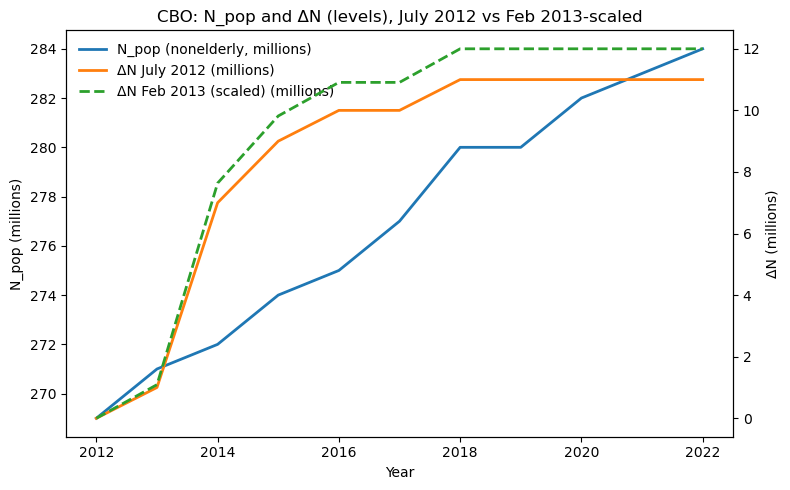

In [4]:

# =============================================================================
# FIGURE 1: N_pop vs ΔN (levels) — July vs Feb-scaled
# =============================================================================

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(cbo_july["year"], cbo_july["N_pop"]/1e6, lw=2, color="C0",
         label="N_pop (nonelderly, millions)")
ax1.set_xlabel("Year")
ax1.set_ylabel("N_pop (millions)")

ax2 = ax1.twinx()
ax2.plot(cbo_july["year"], cbo_july["dN"]/1e6, lw=2, color="C1",
         label="ΔN July 2012 (millions)")
ax2.plot(cbo_feb["year"], cbo_feb["dN"]/1e6, lw=2, color="C2", ls="--",
         label="ΔN Feb 2013 (scaled) (millions)")
ax2.set_ylabel("ΔN (millions)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left")

plt.title("CBO: N_pop and ΔN (levels), July 2012 vs Feb 2013-scaled")
plt.tight_layout()
plt.show()


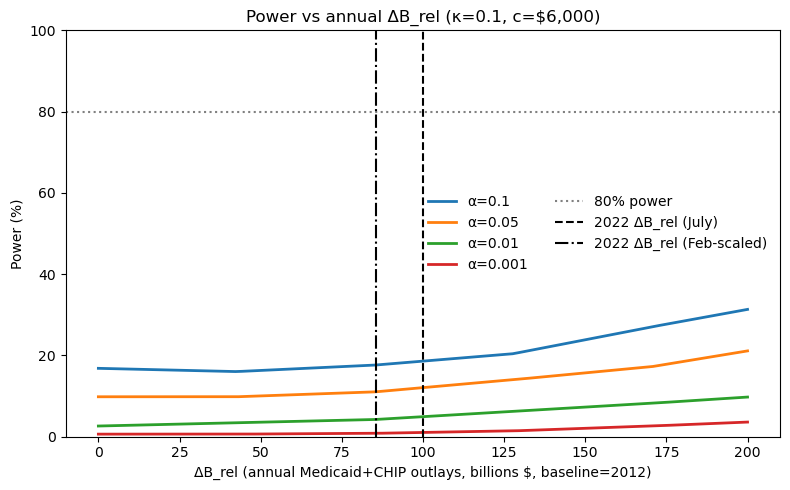

In [5]:

# =============================================================================
# FIGURE 2: Power vs ΔB_rel (annual incremental outlays, baseline=2012)
# =============================================================================

dB_grid = np.linspace(0, float(cbo_july["dB_rel"].max()*2), 200)

plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_effect(a, effect_pct_from_dB(x)) for x in dB_grid]
    plt.plot(dB_grid/1e9, pw, lw=2, label=f"α={a:g}")

plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
plt.axvline(float(cbo_july.loc[cbo_july.year==2022, "dB_rel"].iloc[0])/1e9,
            color="black", ls="--", lw=1.5, label="2022 ΔB_rel (July)")
plt.axvline(float(cbo_feb.loc[cbo_feb.year==2022, "dB_rel"].iloc[0])/1e9,
            color="black", ls="-.", lw=1.5, label="2022 ΔB_rel (Feb-scaled)")

plt.ylim(0,100)
plt.xlabel("ΔB_rel (annual Medicaid+CHIP outlays, billions $, baseline=2012)")
plt.ylabel("Power (%)")
plt.title(f"Power vs annual ΔB_rel (κ={KAPPA_FIX}, c=${C_FIX:,.0f})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

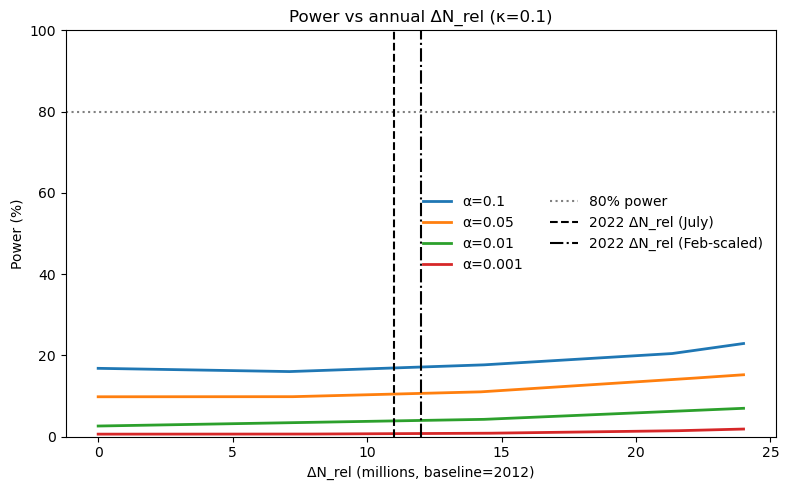

In [6]:


# =============================================================================
# FIGURE 3: Power vs ΔN_rel (annual incremental enrollment, baseline=2012)
# =============================================================================

dN_grid = np.linspace(0, float(cbo_feb["dN_rel"].max()*2), 200)

plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_effect(a, effect_pct_from_dN(x)) for x in dN_grid]
    plt.plot(dN_grid/1e6, pw, lw=2, label=f"α={a:g}")

plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
plt.axvline(float(cbo_july.loc[cbo_july.year==2022, "dN_rel"].iloc[0])/1e6,
            color="black", ls="--", lw=1.5, label="2022 ΔN_rel (July)")
plt.axvline(float(cbo_feb.loc[cbo_feb.year==2022, "dN_rel"].iloc[0])/1e6,
            color="black", ls="-.", lw=1.5, label="2022 ΔN_rel (Feb-scaled)")

plt.ylim(0,100)
plt.xlabel("ΔN_rel (millions, baseline=2012)")
plt.ylabel("Power (%)")
plt.title(f"Power vs annual ΔN_rel (κ={KAPPA_FIX})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

# =============================================================================
# Threshold helper series: ΔN_min,t and ΔB_min,t for an MDE value
# =============================================================================

def dN_min_series(N_pop_series, mde_pct, kappa):
    # ΔN_min,t = N_pop,t * (MDE/κ)
    return N_pop_series * ((mde_pct/100.0) / kappa)

def dB_min_series(N_pop_series, mde_pct, kappa, c):
    return c * dN_min_series(N_pop_series, mde_pct, kappa)


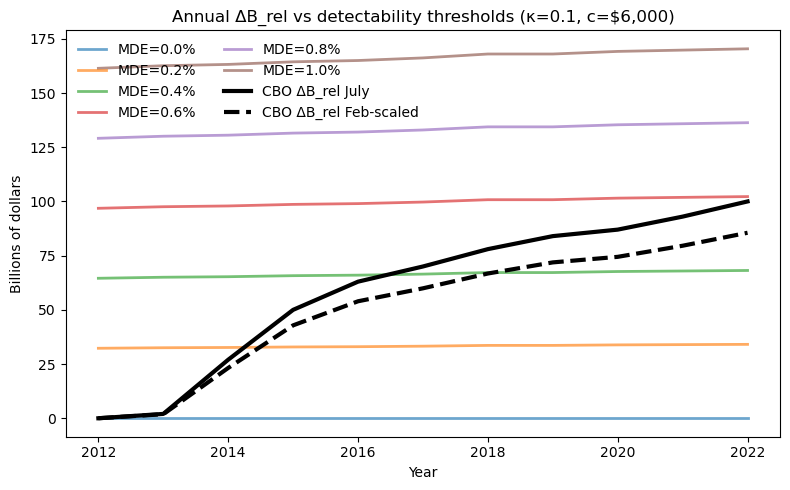

In [7]:

# =============================================================================
# FIGURE 4: Yearly ΔB_rel vs MDE-threshold ΔB_min,t (MDE grid 0..1)
# =============================================================================

plt.figure(figsize=(8,5))

# Plot threshold curves for MDE grid
for mde_pct in MDE_GRID_PCT:
    dB_min = dB_min_series(cbo_july["N_pop"].values, mde_pct, KAPPA_FIX, C_FIX)
    plt.plot(cbo_july["year"], dB_min/1e9, lw=2, alpha=0.65, label=f"MDE={mde_pct:.1f}%")

# Optional: show simulated MDE as a dashed curve (will be huge; may blow up y-axis if shown)
# If you want it, uncomment, but it will dwarf the 0..1% grid.
# dB_min_sim = dB_min_series(cbo_july["N_pop"].values, mde_sim, KAPPA_FIX, C_FIX)
# plt.plot(cbo_july["year"], dB_min_sim/1e9, lw=2, color="red", ls="--", label=f"Sim MDE={mde_sim:.2f}%")

# CBO ΔB_rel lines (July and Feb-scaled)
plt.plot(cbo_july["year"], cbo_july["dB_rel"]/1e9, lw=3, color="black", label="CBO ΔB_rel July")
plt.plot(cbo_feb["year"],  cbo_feb["dB_rel"]/1e9,  lw=3, color="black", ls="--", label="CBO ΔB_rel Feb-scaled")

plt.xlabel("Year")
plt.ylabel("Billions of dollars")
plt.title(f"Annual ΔB_rel vs detectability thresholds (κ={KAPPA_FIX}, c=${C_FIX:,.0f})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()


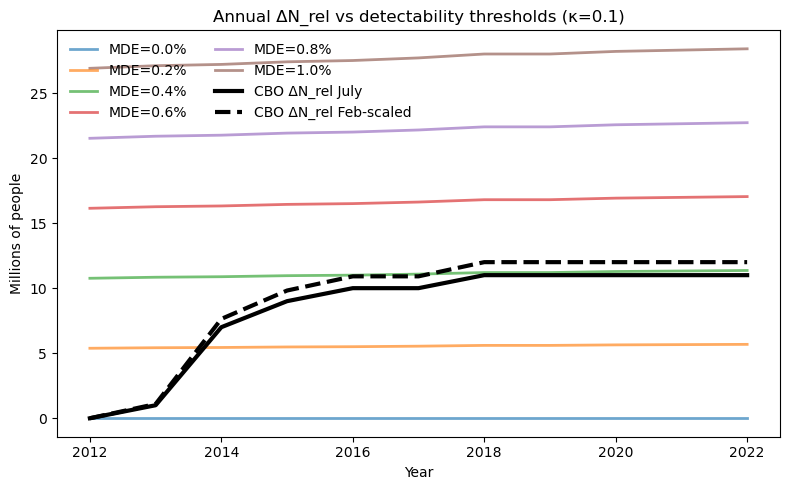

In [8]:

# =============================================================================
# FIGURE 5: Yearly ΔN_rel vs MDE-threshold ΔN_min,t (MDE grid 0..1)
# =============================================================================

plt.figure(figsize=(8,5))

for mde_pct in MDE_GRID_PCT:
    dN_min = dN_min_series(cbo_july["N_pop"].values, mde_pct, KAPPA_FIX)
    plt.plot(cbo_july["year"], dN_min/1e6, lw=2, alpha=0.65, label=f"MDE={mde_pct:.1f}%")

# Optional simulated MDE curve (will be huge)
# dN_min_sim = dN_min_series(cbo_july["N_pop"].values, mde_sim, KAPPA_FIX)
# plt.plot(cbo_july["year"], dN_min_sim/1e6, lw=2, color="red", ls="--", label=f"Sim MDE={mde_sim:.2f}%")

plt.plot(cbo_july["year"], cbo_july["dN_rel"]/1e6, lw=3, color="black", label="CBO ΔN_rel July")
plt.plot(cbo_feb["year"],  cbo_feb["dN_rel"]/1e6,  lw=3, color="black", ls="--", label="CBO ΔN_rel Feb-scaled")

plt.xlabel("Year")
plt.ylabel("Millions of people")
plt.title(f"Annual ΔN_rel vs detectability thresholds (κ={KAPPA_FIX})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()